# Fondo di Solidarietà Comunale 2025 — v1

**Domanda guida**: i comuni con capacità fiscale più bassa ricevono davvero più risorse perequative in proporzione, oppure la dotazione finale FSC 2025 redistribuisce in modo meno intuitivo del previsto?

**Fonte**: OpenCivitas/Sogei — FSC 2025, Metadati Enti FSC 2025. Elaborazione DataCivicLab.

---

**Caveat preliminari:**

- Perimetro: **solo comuni RSO** (Regioni a Statuto Ordinario). Sono esclusi i comuni di Valle d'Aosta, Trentino-Alto Adige, Friuli-Venezia Giulia, Sicilia, Sardegna.
- Anno: **solo 2025**. Non è una serie storica.
- Il `fondo_perequativo` è una componente del FSC, non la dotazione finale. La `dotazione_finale_fsc` include anche le risorse storiche.
- Questa è una lettura descrittiva. Non è una spiegazione causale del meccanismo FSC né un giudizio sull'equità del riparto.
- Questo notebook è il primo passaggio pubblico in `dataciviclab/analisi`.

## In breve

- a livello **regionale** il meccanismo FSC 2025 segue la direzione attesa: dove la capacitÃ  fiscale mediana Ã¨ piÃ¹ bassa, il fondo perequativo tende a essere piÃ¹ alto
- a livello di **singolo comune** la relazione Ã¨ molto meno lineare: il fondo non si distribuisce in semplice proporzione inversa alla capacitÃ  fiscale
- il **25.8% dei comuni RSO** ha `fondo_perequativo` negativo: sono i contribuenti netti al fondo, non i beneficiari
- la **dotazione finale FSC** non coincide con il fondo perequativo, perchÃ© incorpora anche le risorse storiche


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
pd.set_option('display.max_colwidth', 40)


def _find_workspace_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'dataciviclab').exists() and (p / 'dataset-incubator').exists():
            return p
    raise RuntimeError('Workspace root non trovato')


WORKSPACE = _find_workspace_root()
MART = WORKSPACE / 'dataset-incubator' / 'out' / 'data' / 'mart' / 'opencivitas_fsc_2025_rso' / '2025' / 'mart_compose_comuni.parquet'

assert MART.exists(), f'Mart non trovato: {MART}'

df = pd.read_parquet(MART)
df = df[df['regione_istat_cod'].notna()].copy()
print(f'Righe: {len(df):,} | Colonne: {len(df.columns)}')
print(f'Join completo: {df["join_enti_ok"].all()}')
df.head(3)

Righe: 6,557 | Colonne: 15
Join completo: True


,username,comune,provincia,regione,regione_istat_cod,popolazione,capacita_fiscale,fondo_perequativo,dotazione_finale_fsc,imu_tasi_standard,totale_risorse_storiche,capacita_fiscale_procapite,fondo_perequativo_procapite,dotazione_finale_fsc_procapite,join_enti_ok
1,AQ001SIF11QN,ACCIANO,066,ABRUZZO,13.0,256.0,"135,524.7","94,660.2","132,508.8","102,456.0","243,802.0",529.4,369.8,517.6,True
2,AQ002SIF11QO,AIELLI,066,ABRUZZO,13.0,"1,372.0","426,289.1","254,291.8","288,741.2","328,424.2","604,808.2",310.7,185.3,210.5,True
3,AQ003SIF11QP,ALFEDENA,066,ABRUZZO,13.0,926.0,"832,873.7","-322,271.4","-164,397.3","811,909.3","477,167.2",899.4,-348.0,-177.5,True


## 1. Copertura e qualità del mart

In [2]:
print(f"Comuni totali: {len(df):,}")
print(f"Regioni coperte: {df['regione'].nunique()}")
print(f"Comuni con fondo_perequativo >= 0: {(df['fondo_perequativo'] >= 0).sum():,} ({(df['fondo_perequativo'] >= 0).mean()*100:.1f}%)")
print(f"Comuni con fondo_perequativo < 0:  {(df['fondo_perequativo'] < 0).sum():,} ({(df['fondo_perequativo'] < 0).mean()*100:.1f}%)")
print()
print("Statistiche chiave (euro/abitante):")
df[['capacita_fiscale_procapite','fondo_perequativo_procapite','dotazione_finale_fsc_procapite']].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
).round(1)

Comuni totali: 6,557
Regioni coperte: 15
Comuni con fondo_perequativo >= 0: 4,870 (74.3%)
Comuni con fondo_perequativo < 0:  1,687 (25.7%)

Statistiche chiave (euro/abitante):


,capacita_fiscale_procapite,fondo_perequativo_procapite,dotazione_finale_fsc_procapite
count,"6,557.0","6,557.0","6,557.0"
mean,398.0,65.5,153.9
std,304.7,260.0,183.1
min,60.9,"-6,184.8","-2,669.0"
10%,196.0,-72.9,47.1
25%,271.7,-2.1,92.7
50%,341.4,61.2,139.9
75%,421.0,163.6,209.9
90%,586.2,272.0,319.2
max,"7,458.8","1,993.4","2,211.4"


**Nota**: il 25.8% dei comuni ha `fondo_perequativo` negativo. Questi comuni contribuiscono al fondo invece di riceverlo — sono quelli con capacità fiscale più alta. Nei grafici successivi il fondo perequativo viene presentato separatamente per i due gruppi.

## 2. Distribuzione della capacità fiscale per regione

La capacità fiscale pro capite misura la potenziale base tributaria del comune, standardizzata per popolazione.

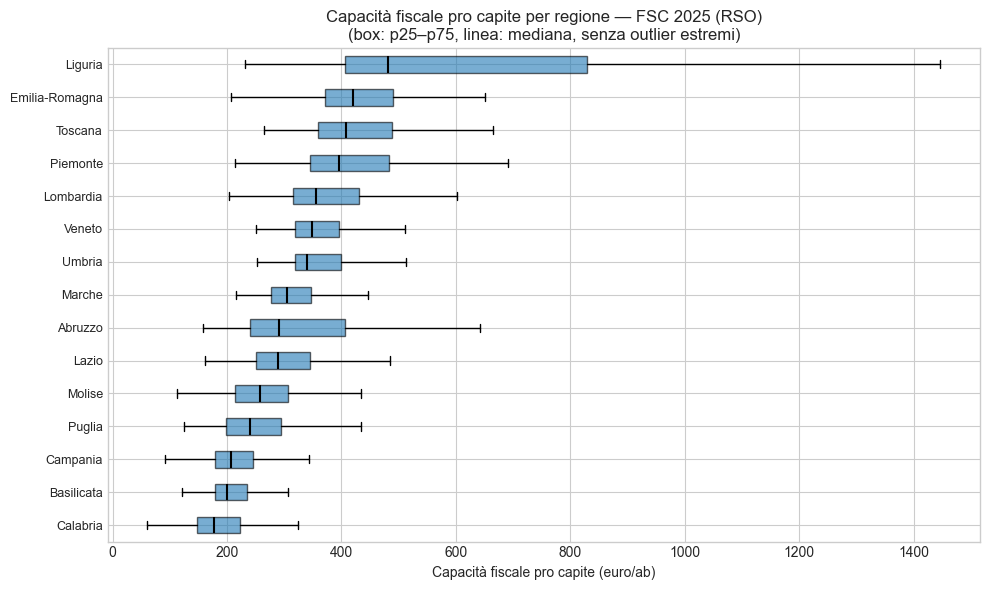

In [3]:
# Ordina regioni per mediana capacità fiscale
order = (
    df.groupby('regione')['capacita_fiscale_procapite']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(10, 6))

data_by_reg = [df.loc[df['regione'] == r, 'capacita_fiscale_procapite'] for r in order]
bp = ax.boxplot(
    data_by_reg,
    vert=False,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='tab:blue', alpha=0.6),
    medianprops=dict(color='black', linewidth=1.5),
)
ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels([r.title() for r in order], fontsize=9)
ax.set_xlabel('Capacità fiscale pro capite (euro/ab)')
ax.set_title('Capacità fiscale pro capite per regione — FSC 2025 (RSO)\n(box: p25–p75, linea: mediana, senza outlier estremi)')
plt.tight_layout()
plt.show()

## 3. Il fondo perequativo: chi riceve e chi contribuisce

Il fondo perequativo ha segno positivo per i comuni che ricevono risorse e negativo per quelli che contribuiscono al fondo. I contribuenti netti sono i comuni con alta capacità fiscale.

In [4]:
# Aggrega per regione: mediana capacità fiscale vs mediana fondo perequativo
reg = (
    df.groupby('regione')
    .agg(
        n_comuni=('comune', 'count'),
        mediana_cap_fiscale=('capacita_fiscale_procapite', 'median'),
        mediana_fondo_perequativo=('fondo_perequativo_procapite', 'median'),
        mediana_dotazione_fsc=('dotazione_finale_fsc_procapite', 'median'),
    )
    .sort_values('mediana_cap_fiscale')
)

print("Aggregazione per regione (mediane, euro/ab):")
reg[['n_comuni','mediana_cap_fiscale','mediana_fondo_perequativo','mediana_dotazione_fsc']].rename(columns={
    'n_comuni': 'N comuni',
    'mediana_cap_fiscale': 'Cap. fiscale (mediana)',
    'mediana_fondo_perequativo': 'Fondo perequativo (mediana)',
    'mediana_dotazione_fsc': 'Dotazione finale (mediana)',
})

Aggregazione per regione (mediane, euro/ab):


,N comuni,Cap. fiscale (mediana),Fondo perequativo (mediana),Dotazione finale (mediana)
regione,,,,
CALABRIA,404,176.7,258.7,267.8
BASILICATA,131,200.5,268.7,310.9
CAMPANIA,550,206.8,178.4,203.1
PUGLIA,257,239.5,133.7,156.2
MOLISE,136,257.1,254.6,266.3
LAZIO,378,289.3,123.9,160.2
ABRUZZO,305,290.5,164.8,210.5
MARCHE,225,304.9,106.0,160.8
UMBRIA,92,340.2,89.0,163.2


## 4. Scatter principale: capacità fiscale vs fondo perequativo

La domanda guida chiede se i comuni con capacità fiscale più bassa ricevono più fondo perequativo. Il grafico mostra la relazione a livello di singolo comune, separando chi riceve (fondo > 0) da chi contribuisce (fondo < 0).

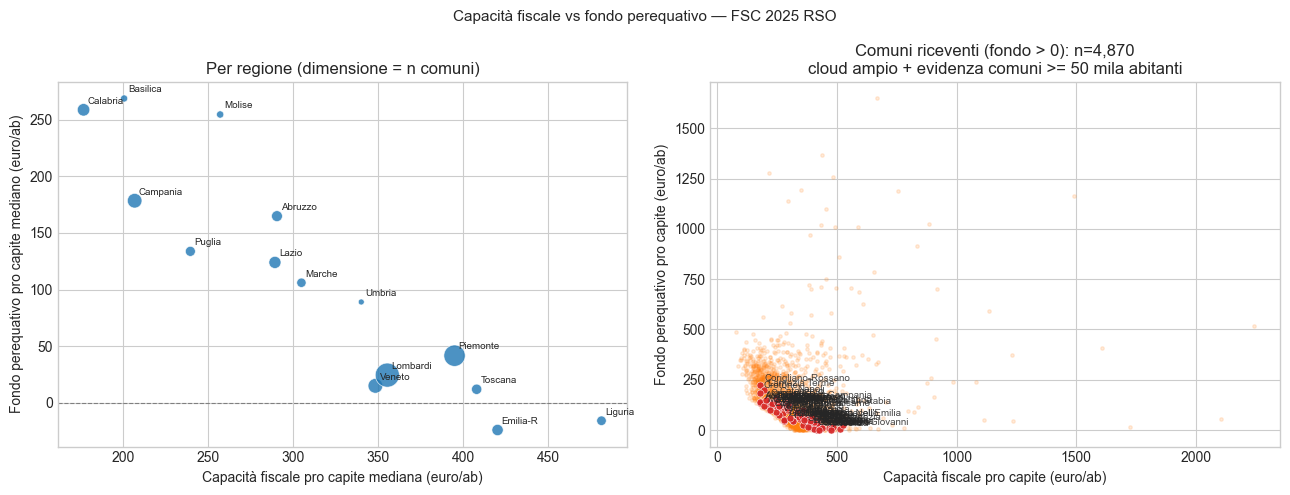

Correlazione (comuni riceventi): capacità fiscale vs fondo perequativo = -0.043


In [5]:
# Scatter a livello regionale (mediane) — più leggibile del singolo comune
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Sinistra: livello regionale ---
ax = axes[0]
ax.scatter(
    reg['mediana_cap_fiscale'],
    reg['mediana_fondo_perequativo'],
    s=reg['n_comuni'] / 5,
    alpha=0.8,
    color='tab:blue',
    edgecolors='white',
    linewidths=0.5,
)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
for _, row in reg.iterrows():
    ax.annotate(
        row.name.title()[:8],
        (row['mediana_cap_fiscale'], row['mediana_fondo_perequativo']),
        fontsize=7, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points'
    )
ax.set_xlabel('Capacità fiscale pro capite mediana (euro/ab)')
ax.set_ylabel('Fondo perequativo pro capite mediano (euro/ab)')
ax.set_title('Per regione (dimensione = n comuni)')

# --- Destra: singoli comuni, solo quelli con fondo > 0 (riceventi) ---
ax = axes[1]
riceventi = df[df['fondo_perequativo_procapite'] > 0]
# Campiona per leggibilità
sample = riceventi.sample(min(2000, len(riceventi)), random_state=42)
grandi_riceventi = riceventi[riceventi['popolazione'] >= 50_000].copy()
ax.scatter(
    sample['capacita_fiscale_procapite'],
    sample['fondo_perequativo_procapite'],
    alpha=0.15,
    s=6,
    color='tab:orange',
)
ax.scatter(
    grandi_riceventi['capacita_fiscale_procapite'],
    grandi_riceventi['fondo_perequativo_procapite'],
    alpha=0.9,
    s=26,
    color='tab:red',
    edgecolors='white',
    linewidths=0.4,
)
for _, row in grandi_riceventi.iterrows():
    ax.annotate(
        row['comune'].title(),
        (row['capacita_fiscale_procapite'], row['fondo_perequativo_procapite']),
        xytext=(3, 3),
        textcoords='offset points',
        fontsize=7,
        alpha=0.85,
    )
ax.set_xlabel('Capacità fiscale pro capite (euro/ab)')
ax.set_ylabel('Fondo perequativo pro capite (euro/ab)')
ax.set_title(f'Comuni riceventi (fondo > 0): n={len(riceventi):,}\ncloud ampio + evidenza comuni >= 50 mila abitanti')

fig.suptitle('Capacità fiscale vs fondo perequativo — FSC 2025 RSO', fontsize=11)
plt.tight_layout()
plt.show()

corr = riceventi['capacita_fiscale_procapite'].corr(riceventi['fondo_perequativo_procapite'])
print(f"Correlazione (comuni riceventi): capacità fiscale vs fondo perequativo = {corr:.3f}")

## 5. Capacità fiscale vs dotazione finale FSC

La dotazione finale include anche le risorse storiche, non solo la componente perequativa. Per molti comuni del Nord la dotazione finale rimane positiva anche quando il fondo perequativo è negativo.

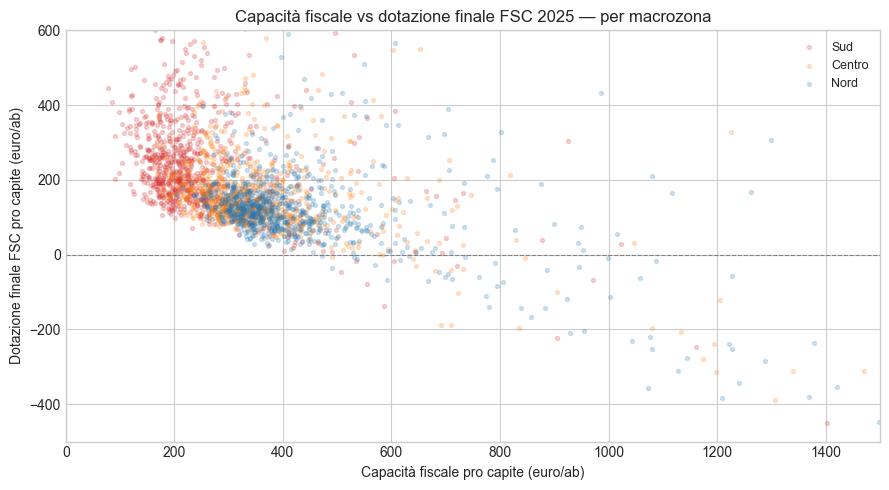

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

# Colora per macrozona
sud = ['CALABRIA', 'BASILICATA', 'CAMPANIA', 'PUGLIA', 'MOLISE', 'ABRUZZO']
centro = ['LAZIO', 'MARCHE', 'UMBRIA', 'TOSCANA']

for label, mask, color in [
    ('Sud', df['regione'].isin(sud), 'tab:red'),
    ('Centro', df['regione'].isin(centro), 'tab:orange'),
    ('Nord', ~df['regione'].isin(sud + centro), 'tab:blue'),
]:
    sub = df[mask].sample(min(800, mask.sum()), random_state=42)
    ax.scatter(
        sub['capacita_fiscale_procapite'],
        sub['dotazione_finale_fsc_procapite'],
        alpha=0.2,
        s=8,
        color=color,
        label=label,
    )

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Capacità fiscale pro capite (euro/ab)')
ax.set_ylabel('Dotazione finale FSC pro capite (euro/ab)')
ax.set_title('Capacità fiscale vs dotazione finale FSC 2025 — per macrozona')
ax.legend(fontsize=9)
ax.set_xlim(0, 1500)  # taglia gli outlier estremi per leggibilità
ax.set_ylim(-500, 600)
plt.tight_layout()
plt.show()

## 6. Tabella: casi estremi e casi di interesse

Una selezione di casi che illustrano i pattern principali.

In [7]:
COLS = ['comune', 'regione', 'popolazione',
        'capacita_fiscale_procapite', 'fondo_perequativo_procapite', 'dotazione_finale_fsc_procapite']

# Comuni con pop >= 10.000 per evitare micro-comuni con numeri anomali
grandi = df[df['popolazione'] >= 10_000].copy()

print(f"=== Comuni (pop >= 10.000) con capacità fiscale più alta — top 10 ===")
print(grandi.nlargest(10, 'capacita_fiscale_procapite')[COLS].to_string(index=False))

print(f"\n=== Comuni (pop >= 10.000) con capacità fiscale più bassa — bottom 10 ===")
print(grandi.nsmallest(10, 'capacita_fiscale_procapite')[COLS].to_string(index=False))

print(f"\n=== Comuni (pop >= 10.000) con dotazione finale FSC più alta — top 10 ===")
print(grandi.nlargest(10, 'dotazione_finale_fsc_procapite')[COLS].to_string(index=False))

print(f"\n=== Comuni (pop >= 10.000) con dotazione finale FSC più bassa (negativi) — bottom 10 ===")
print(grandi.nsmallest(10, 'dotazione_finale_fsc_procapite')[COLS].to_string(index=False))

=== Comuni (pop >= 10.000) con capacità fiscale più alta — top 10 ===
                    comune        regione  popolazione  capacita_fiscale_procapite  fondo_perequativo_procapite  dotazione_finale_fsc_procapite
                   ALASSIO        LIGURIA     10,064.0                     1,690.4                     -1,115.2                          -608.0
SAN MICHELE AL TAGLIAMENTO         VENETO     11,347.0                     1,215.1                       -483.1                          -262.2
             FINALE LIGURE        LIGURIA     11,064.0                     1,213.4                       -632.5                          -268.2
                     LOANO        LIGURIA     10,709.0                     1,209.2                       -649.9                          -382.2
                   VARAZZE        LIGURIA     12,539.0                     1,134.6                       -640.6                          -222.5
                 COMACCHIO EMILIA-ROMAGNA     22,037.0            

## Note operative

**Cosa emerge dal v1:**

- A livello **regionale** il meccanismo funziona come atteso: le regioni del Sud (Calabria, Basilicata, Campania) hanno la capacità fiscale mediana più bassa e il fondo perequativo mediano più alto.
- A livello di **singolo comune** la relazione è molto più rumorosa: la correlazione tra capacità fiscale e fondo perequativo tra i comuni riceventi è quasi nulla (~-0.04). Il meccanismo non redistribuisce semplicemente in proporzione inversa alla capacità fiscale.
- Il **25.8% dei comuni RSO** ha fondo perequativo negativo: sono i contribuenti netti, quasi tutti comuni ad alta capacità fiscale (destinazioni turistiche, comuni montani con bassa popolazione e alta base IMU).
- La **dotazione finale** è diversa dal fondo perequativo perché include le risorse storiche. Molti comuni del Nord ricevono una dotazione finale positiva anche con fondo perequativo negativo.

**Rischi residui:**

- I dati 2025 potrebbero includere componenti provvisorie o in revisione — OpenCivitas aggiorna il dato durante l'anno.
- Il perimetro RSO esclude circa 1.500 comuni. Qualsiasi lettura che parli di "tutti i comuni italiani" è sbagliata.
- La serie storica non è verificata: non assumere che la struttura del file sia omogenea negli anni precedenti.
- Questo v0 non entra nel dettaglio del calcolo delle componenti FSC (fabbisogni standard, capacità fiscale standard, quote storiche). Per una lettura del meccanismo serve documentazione tecnica specifica.

**Fonte**: OpenCivitas/Sogei, FSC 2025. Elaborazione DataCivicLab — mart `opencivitas_fsc_2025_rso`.